In [2]:
import os
import csv
from chi_squared_fitter import ChiSquaredFitter

# Path to your data file
dat_path = '/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/winstonlist.dat'

# Output CSV path for incremental results
output_csv = 'fit_results.csv'

# Load all lines once
with open(dat_path, 'r') as f:
    all_lines = f.readlines()

num_lines = len(all_lines)

# Function to parse a line into mags, errs, av, mass
def parse_line(line):
    parts = line.strip().split()
    parts = [float(x) for x in parts]
    f162m, err_f162m = parts[2], parts[3]
    f182m, err_f182m = parts[4], parts[5]
    f200w, err_f200w = parts[6], parts[7]
    av = parts[8]
    mass = parts[9]
    mags = [f162m, f182m, f200w]
    errs = [err_f162m, err_f182m, err_f200w]
    return mags, errs, av, mass

# Read processed indices if output file exists
processed_indices = set()
if os.path.exists(output_csv):
    with open(output_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            processed_indices.add(int(row['index']))

# Initialize fitter once
fitter = ChiSquaredFitter(output_dir='./fit_plots_test')

# Open CSV in append mode to save results incrementally
write_header = not os.path.exists(output_csv)
with open(output_csv, 'a', newline='') as csvfile:
    fieldnames = ['index', 'best_mass', 'best_AV', 'mass_min', 'mass_max', 'AV_min', 'AV_max', 'intersects', 'min_chi2']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    if write_header:
        writer.writeheader()

    for idx, line in enumerate(all_lines):
        if idx in processed_indices:
            print(f"Skipping line {idx}, already processed")
            continue

        mags, errs, av_true, mass_true = parse_line(line)
        print(f"Processing line {idx} ...")
        result = fitter.analyze_line(idx, mags, errs, av_true, mass_true)

        # Save result immediately
        writer.writerow({
            'index': result['index'],
            'best_mass': result['best_mass'],
            'best_AV': result['best_AV'],
            'mass_min': result['mass_min'],
            'mass_max': result['mass_max'],
            'AV_min': result['AV_min'],
            'AV_max': result['AV_max'],
            'intersects': result['intersects'],
            'min_chi2': result['min_chi2']
        })
        csvfile.flush()

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


Skipping line 0, already processed
Skipping line 1, already processed
Skipping line 2, already processed
Skipping line 3, already processed
Skipping line 4, already processed
Skipping line 5, already processed
Skipping line 6, already processed
Skipping line 7, already processed
Skipping line 8, already processed
Skipping line 9, already processed
Skipping line 10, already processed
Skipping line 11, already processed
Skipping line 12, already processed
Skipping line 13, already processed
Skipping line 14, already processed
Skipping line 15, already processed
Skipping line 16, already processed
Skipping line 17, already processed
Skipping line 18, already processed
Skipping line 19, already processed
Skipping line 20, already processed
Skipping line 21, already processed
Skipping line 22, already processed
Skipping line 23, already processed
Skipping line 24, already processed
Skipping line 25, already processed
Skipping line 26, already processed
Skipping line 27, already processed
Sk

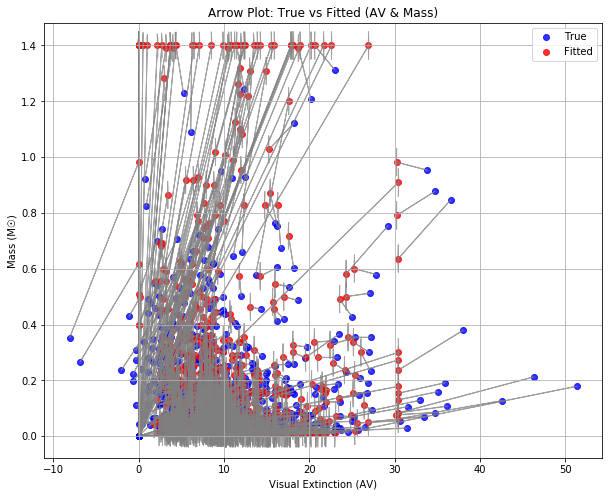

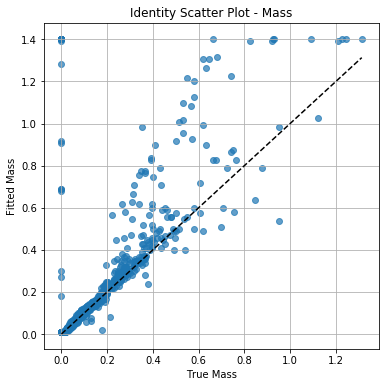

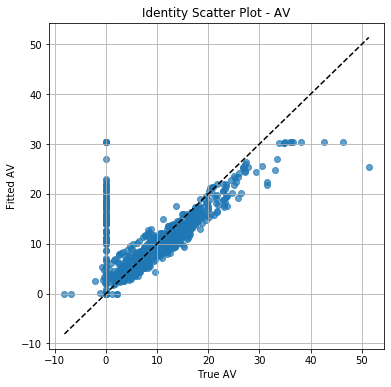

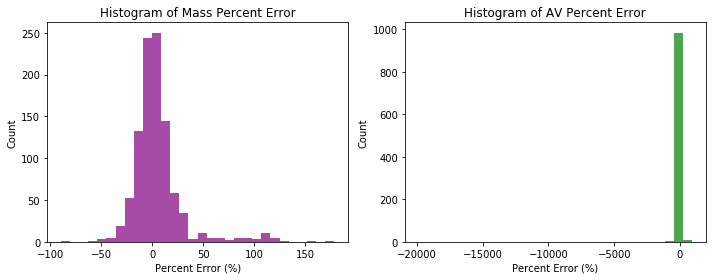

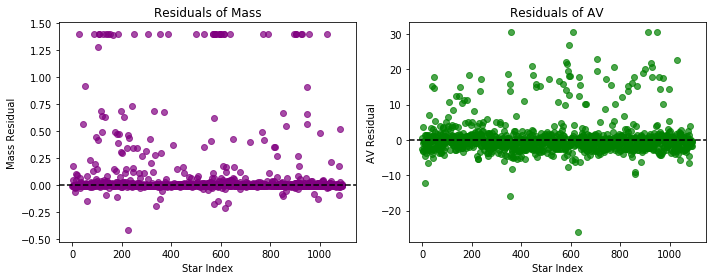

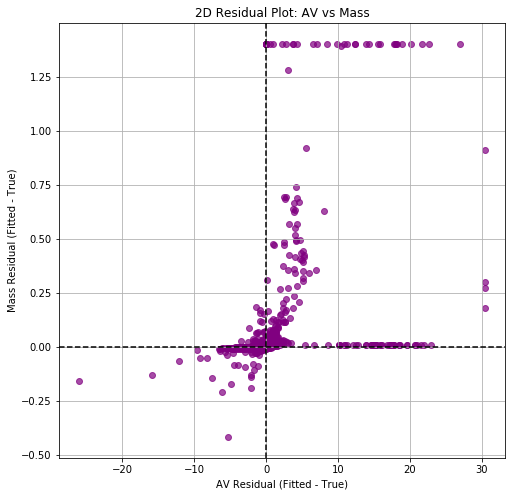

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the full results
df = pd.read_csv(output_csv)

# Reload ground truth from your original data file
true_avs = []
true_masses = []
for line in all_lines:
    parts = line.strip().split()
    parts = [float(x) for x in parts]
    true_avs.append(parts[8])
    true_masses.append(parts[9])

df['true_AV'] = true_avs[:len(df)]
df['true_mass'] = true_masses[:len(df)]

# Calculate errors
df['mass_error'] = df['best_mass'] - df['true_mass']
df['AV_error'] = df['best_AV'] - df['true_AV']

# Safely calculate percent errors, avoiding division by zero
df['mass_pct_error'] = np.where(
    df['true_mass'] != 0,
    df['mass_error'] / df['true_mass'] * 100,
    np.nan  # or any sentinel value you prefer
)

df['AV_pct_error'] = np.where(
    df['true_AV'] != 0,
    df['AV_error'] / df['true_AV'] * 100,
    np.nan
)

# === 2D Arrow Plot (joint mass & AV errors) ===
plt.figure(figsize=(10, 8))
for i, row in df.iterrows():
    plt.arrow(row['true_AV'], row['true_mass'],
              row['best_AV'] - row['true_AV'],
              row['best_mass'] - row['true_mass'],
              head_width=0.1, head_length=0.05, fc='gray', ec='gray', alpha=0.7)

plt.scatter(df['true_AV'], df['true_mass'], color='blue', label='True', alpha=0.8)
plt.scatter(df['best_AV'], df['best_mass'], color='red', label='Fitted', alpha=0.8)

plt.xlabel('Visual Extinction (AV)')
plt.ylabel('Mass (M☉)')
plt.title('Arrow Plot: True vs Fitted (AV & Mass)')
plt.legend()
plt.grid(True)
plt.show()

# === Identity scatter plots ===
plt.figure(figsize=(6,6))
plt.scatter(df['true_mass'], df['best_mass'], alpha=0.7)
plt.plot([df['true_mass'].min(), df['true_mass'].max()], 
         [df['true_mass'].min(), df['true_mass'].max()], 'k--')
plt.xlabel('True Mass')
plt.ylabel('Fitted Mass')
plt.title('Identity Scatter Plot - Mass')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df['true_AV'], df['best_AV'], alpha=0.7)
plt.plot([df['true_AV'].min(), df['true_AV'].max()], 
         [df['true_AV'].min(), df['true_AV'].max()], 'k--')
plt.xlabel('True AV')
plt.ylabel('Fitted AV')
plt.title('Identity Scatter Plot - AV')
plt.grid(True)
plt.show()

# === Histograms of Percent Error ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['mass_pct_error'].dropna(), bins=30, color='purple', alpha=0.7)  # drop NaNs here
plt.title('Histogram of Mass Percent Error')
plt.xlabel('Percent Error (%)')
plt.ylabel('Count')

plt.subplot(1,2,2)
plt.hist(df['AV_pct_error'].dropna(), bins=30, color='green', alpha=0.7)  # drop NaNs here
plt.title('Histogram of AV Percent Error')
plt.xlabel('Percent Error (%)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# === Residual plots ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(range(len(df)), df['mass_error'], color='purple', alpha=0.7)
plt.axhline(0, color='k', linestyle='--')
plt.title('Residuals of Mass')
plt.xlabel('Star Index')
plt.ylabel('Mass Residual')

plt.subplot(1,2,2)
plt.scatter(range(len(df)), df['AV_error'], color='green', alpha=0.7)
plt.axhline(0, color='k', linestyle='--')
plt.title('Residuals of AV')
plt.xlabel('Star Index')
plt.ylabel('AV Residual')

plt.tight_layout()
plt.show()

# === 2D Residual Scatter Plot ===
plt.figure(figsize=(8, 8))
plt.scatter(df['AV_error'], df['mass_error'], alpha=0.7, color='purple')
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('AV Residual (Fitted - True)')
plt.ylabel('Mass Residual (Fitted - True)')
plt.title('2D Residual Plot: AV vs Mass')
plt.grid(True)
plt.show()